# Benchmark results visualized

In [189]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

OUT = Path('benchmark_results') if Path('benchmark_results').exists() else Path('benchmarks/benchmark_results')
throughput = pd.read_csv(OUT / 'throughput.csv')
footprint = pd.read_csv(OUT / 'footprint.csv')
codesize = pd.read_csv(OUT / 'codesize.csv')
keyschedule = pd.read_csv(OUT / 'keyschedule.csv')

## Throughput, runtime, and speedup vs. input size

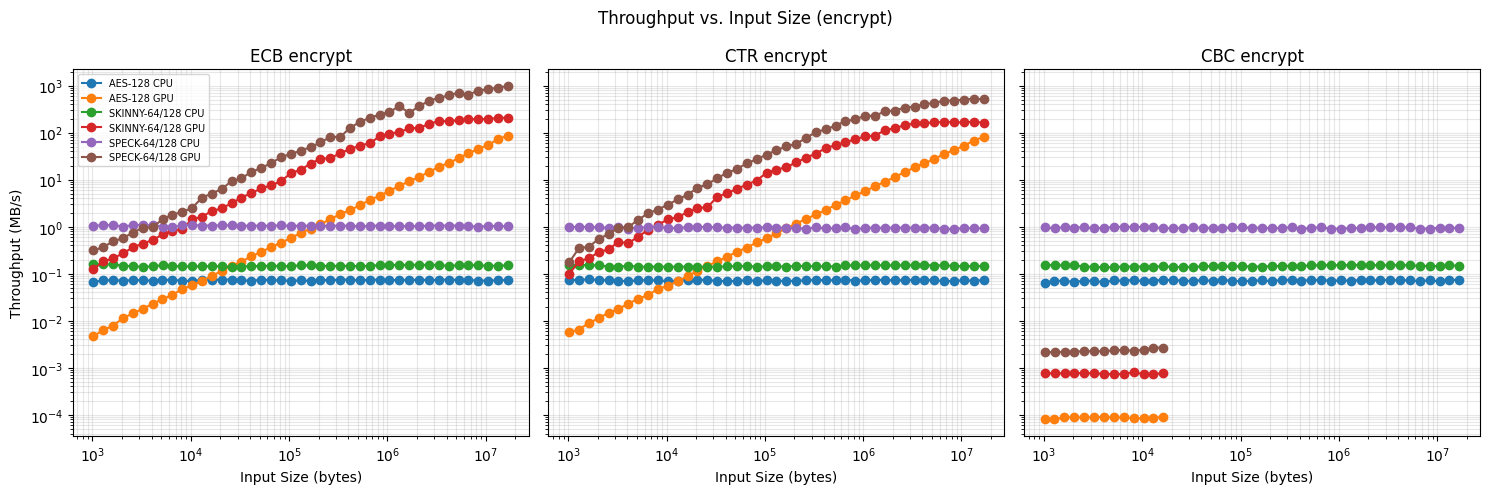

In [190]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
enc = throughput[throughput.op == 'encrypt']
for ax, mode in zip(axes, ['ecb', 'ctr', 'cbc']):
    for (cipher, device), g in enc[enc["mode"] == mode].groupby(['cipher', 'device']):
        g = g.sort_values('bytes')
        ax.plot(g.bytes, g.mb_per_s, marker='o', label=f'{cipher} {device}')
    ax.set(xscale='log', yscale='log', title=f'{mode.upper()} encrypt', xlabel='Input Size (bytes)')
    ax.grid(True, which='both', alpha=0.3)
axes[0].set_ylabel('Throughput (MB/s)')
axes[0].legend(fontsize=7)
fig.suptitle('Throughput vs. Input Size (encrypt)')
plt.tight_layout()
plt.show()

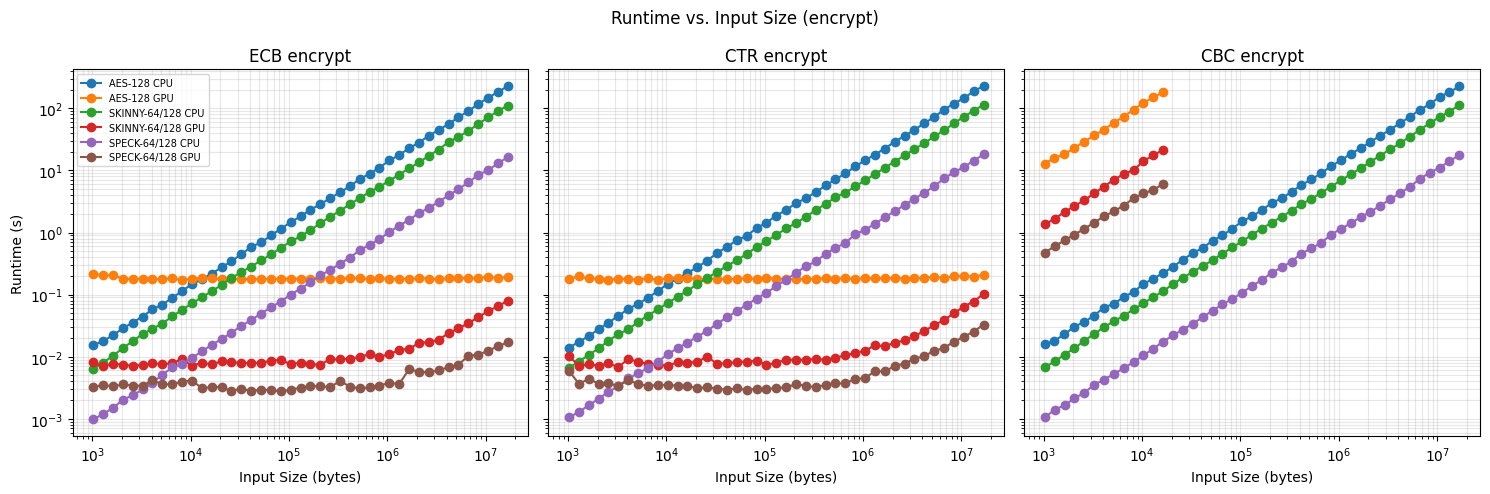

In [191]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
enc = throughput[throughput.op == 'encrypt']
for ax, mode in zip(axes, ['ecb', 'ctr', 'cbc']):
    for (cipher, device), g in enc[enc["mode"] == mode].groupby(['cipher', 'device']):
        g = g.sort_values('bytes')
        ax.plot(g.bytes, g.median_s, marker='o', label=f'{cipher} {device}')
    ax.set(xscale='log', yscale='log', title=f'{mode.upper()} encrypt', xlabel='Input Size (bytes)')
    ax.grid(True, which='both', alpha=0.3)
axes[0].set_ylabel('Runtime (s)')
axes[0].legend(fontsize=7)
fig.suptitle('Runtime vs. Input Size (encrypt)')
plt.tight_layout()
plt.show()

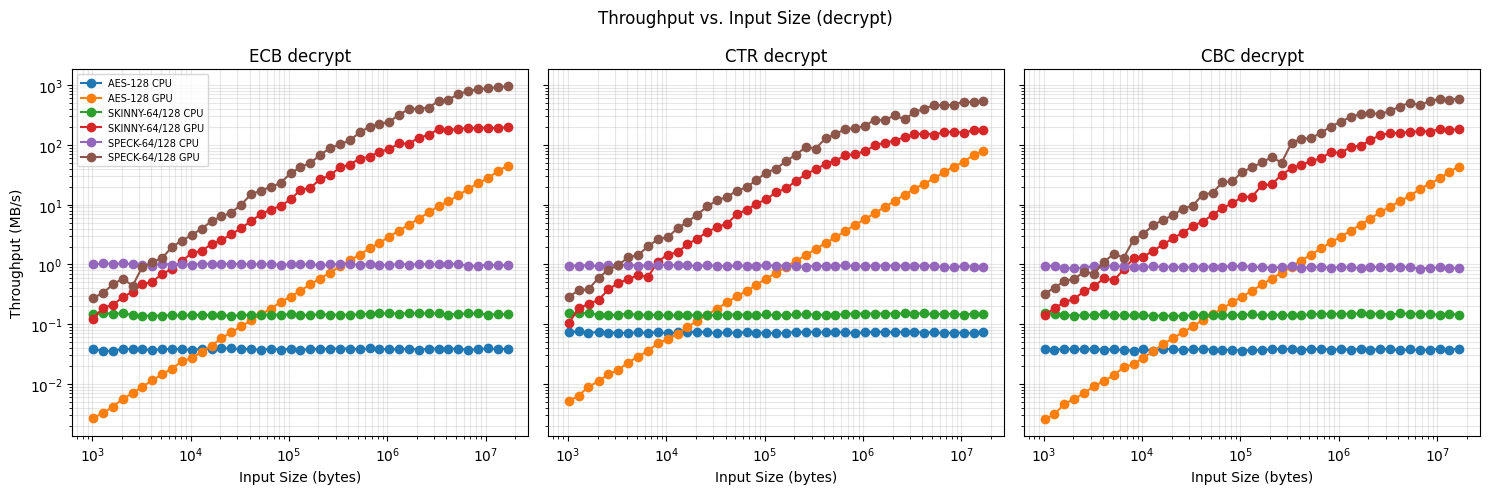

In [192]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
dec = throughput[throughput.op == 'decrypt']
for ax, mode in zip(axes, ['ecb', 'ctr', 'cbc']):
    for (cipher, device), g in dec[dec["mode"] == mode].groupby(['cipher', 'device']):
        g = g.sort_values('bytes')
        ax.plot(g.bytes, g.mb_per_s, marker='o', label=f'{cipher} {device}')
    ax.set(xscale='log', yscale='log', title=f'{mode.upper()} decrypt', xlabel='Input Size (bytes)')
    ax.grid(True, which='both', alpha=0.3)
axes[0].set_ylabel('Throughput (MB/s)')
axes[0].legend(fontsize=7)
fig.suptitle('Throughput vs. Input Size (decrypt)')
plt.tight_layout()
plt.show()

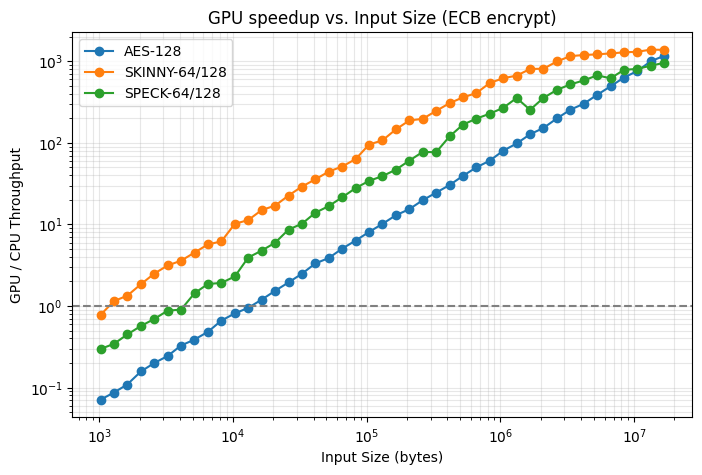

In [193]:
ecb_enc = throughput[(throughput.op == 'encrypt') & (throughput["mode"] == 'ecb')]
fig, ax = plt.subplots(figsize=(8, 5))
for cipher, g in ecb_enc.groupby('cipher'):
    p = g.pivot_table(index='bytes', columns='device', values='mb_per_s')
    ax.plot(p.index, p['GPU'] / p['CPU'], marker='o', label=cipher)
ax.axhline(1, color='gray', ls='--')
ax.set(xscale='log', yscale='log', xlabel='Input Size (bytes)', ylabel='GPU / CPU Throughput', title='GPU speedup vs. Input Size (ECB encrypt)')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
plt.show()

## Static footprint, code size, and key schedule

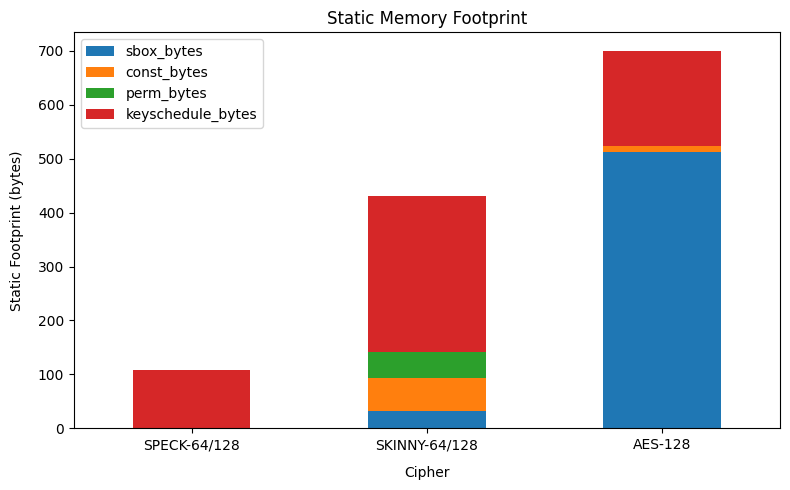

In [194]:
footprint.set_index('cipher')[['sbox_bytes', 'const_bytes', 'perm_bytes', 'keyschedule_bytes']].plot(kind='bar', stacked=True, figsize=(8, 5), rot=0)
plt.ylabel('Static Footprint (bytes)', labelpad=10)
plt.title('Static Memory Footprint')
plt.xlabel('Cipher', labelpad=10)
plt.tight_layout()
plt.show()

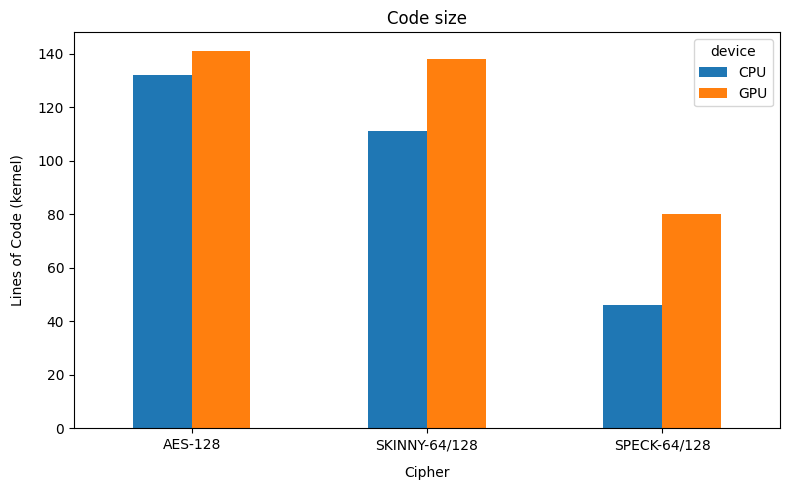

In [195]:
codesize.pivot_table(index='cipher', columns='device', values='loc').plot(kind='bar', figsize=(8, 5), rot=0)
plt.ylabel('Lines of Code (kernel)', labelpad=10)
plt.title('Code size')
plt.xlabel('Cipher', labelpad=10)
plt.tight_layout()
plt.show()

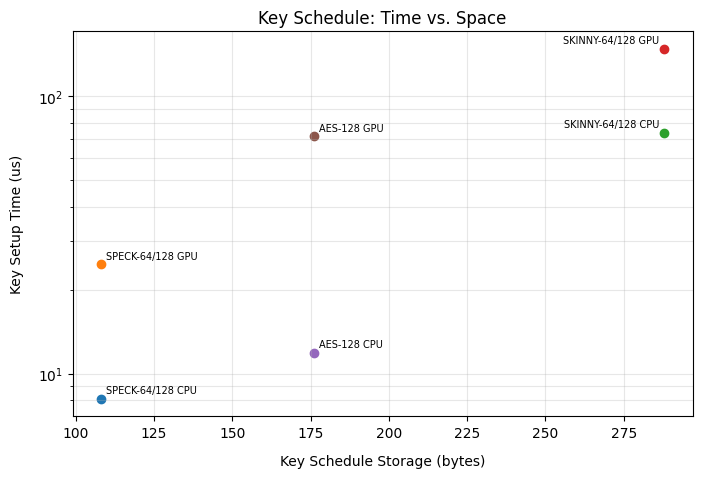

In [196]:
fig, ax = plt.subplots(figsize=(8, 5))
xmax = keyschedule.keyschedule_bytes.max()
for _, r in keyschedule.iterrows():
    ax.scatter(r.keyschedule_bytes, r.setup_s_median * 1e6)
    near_right = r.keyschedule_bytes > 0.7 * xmax
    ax.annotate(f'{r.cipher} {r.device}', (r.keyschedule_bytes, r.setup_s_median * 1e6), fontsize=7, xytext=(-4, 4) if near_right else (4, 4), ha='right' if near_right else 'left', textcoords='offset points')
ax.set(yscale='log', title='Key Schedule: Time vs. Space')
ax.set_ylabel('Key Setup Time (us)', labelpad=10)
ax.set_xlabel('Key Schedule Storage (bytes)', labelpad=10)
ax.grid(True, which='both', alpha=0.3)
plt.show()

## GPU transfer vs. compute

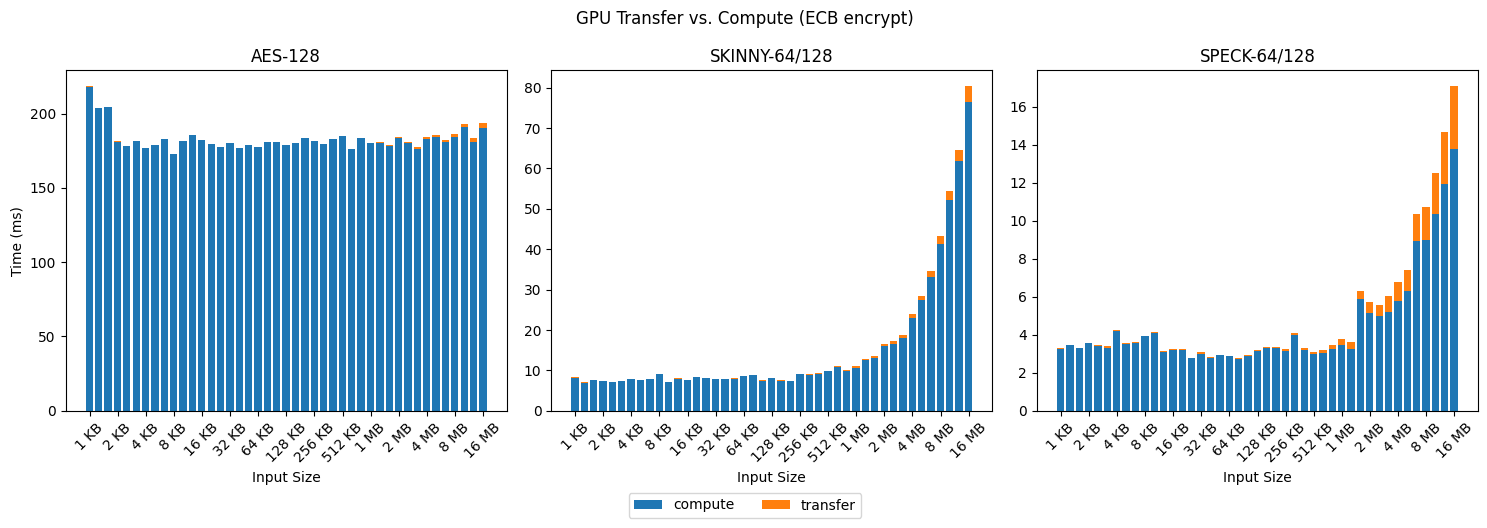

In [197]:
g = throughput[(throughput.op == 'encrypt') & (throughput["mode"] == 'ecb') & (throughput.device == 'GPU')]
ciphers = sorted(g.cipher.unique())
fig, axes = plt.subplots(1, len(ciphers), figsize=(5 * len(ciphers), 5), squeeze=False)

def fmt_bytes(n, _=None):
    if n < 1024**2:
        return f'{n/1024:.0f} KB'
    return f'{n/1024**2:.0f} MB'

for ax, cipher in zip(axes[0], ciphers):
    s = g[g.cipher == cipher].sort_values('bytes')
    x = s.bytes.values
    w = x * 0.18
    ax.bar(x, s.compute_est_s * 1e3, width=w, label='compute')
    ax.bar(x, s.transfer_s * 1e3, bottom=s.compute_est_s * 1e3, width=w, label='transfer')
    ax.set(title=cipher, xlabel='Input Size')
    ax.set_xscale('log')
    ax.xaxis.set_major_locator(mticker.LogLocator(base=2, numticks=20))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_bytes))
    ax.xaxis.set_minor_locator(mticker.NullLocator())
    ax.tick_params(axis='x', rotation=45)

axes[0][0].set_ylabel('Time (ms)')
fig.suptitle('GPU Transfer vs. Compute (ECB encrypt)')
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()